# Transfer learning / fine-tuning

## Procedure

We will first load the Kaggle Cats and Dogs dataset and remove its final layer, the 1000-class softmax classification layer specific to ImageNet, and replace it with a new classification layer for the classes we are training over. We will then freeze all the weights in the network except the new ones connecting to the new classification layer, and then train the new classification layer over our new dataset.

We will also compare this method to training a small neural network from scratch on the new dataset, and as we shall see, it will dramatically improve our accuracy. We will do that part first.

As our test subject, we'll use a dataset consisting of around 24939 images belonging to 2 classes, and train an image classifier with around 80% accuracy on it. It's worth noting that this strategy scales well to image sets where you may have even just a couple hundred or less images. Its performance will be lesser from a small number of samples (depending on classes) as usual, but still impressive considering the usual constraints.

In [2]:
%matplotlib inline

import os

import random
import numpy as np
import keras

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, Activation, MaxPooling2D, Dropout, Flatten, Dense

import shutil

from PIL import Image


### Getting a dataset

The first step is going to be to load our data with two categories: Cats and Dogs.

Using kagglecatsanddogs_5340.zip from the Kaggle download page https://www.microsoft.com/en-us/download/details.aspx?id=54765

In [3]:
!echo "Downloading 101_Object_Categories for image notebooks"
!curl -L -o caltech-101.zip --progress-bar https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
!unzip caltech-101.zip
!rm caltech-101.zip
!ls


Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  
  inflating: PetImages/Dog/5523.jpg  

The message `InvalidArgumentError: Input is empty during model training` was showed during the training model. It typically means that one or more image files in the dataset are corrupted or empty, and TensorFlow's image decoder cannot process them. This is a common issue with the 'Kaggle Cats and Dogs' dataset. To resolve this, I need to preprocess each image directories to remove any invalid files before creating your datasets. Since the actual fix involves cleaning the PetImages directory before train_ds and val_ds are created, it cannot be applied directly to the selected model.fit cell. Adding here a new code cell before the dataset creation to clean up these files.

In [4]:
# Define the root directory where your images are stored
root_dir = 'PetImages'

# List of directories to check (Cat and Dog folders)
class_dirs = ['Cat', 'Dog']

for class_name in class_dirs:
    path = os.path.join(root_dir, class_name)
    for file_name in os.listdir(path):
        file_path = os.path.join(path, file_name)

        # Skip if it's not a file (e.g., a directory) or if it's a zero-byte file
        if not os.path.isfile(file_path):
            print(f"Skipping non-file entry: {file_path}")
            continue

        if os.path.getsize(file_path) == 0:
            print(f"Deleting zero-byte file: {file_path}")
            os.remove(file_path)
            continue # Move to the next file

        try:
            # Try to open the image with Pillow (PIL)
            with Image.open(file_path) as img:
                img.verify() # Verify that it is, in fact, an image

        except (IOError, SyntaxError, OSError) as e:
            # If opening, verifying, or loading fails, it's a bad image file
            print(f"Deleting corrupted/invalid file: {file_path} (Error: {e})")
            os.remove(file_path)

print("Dataset cleaning complete.")

Deleting zero-byte file: PetImages/Cat/666.jpg
Deleting corrupted/invalid file: PetImages/Cat/Thumbs.db (Error: cannot identify image file 'PetImages/Cat/Thumbs.db')
Deleting zero-byte file: PetImages/Dog/11702.jpg
Deleting corrupted/invalid file: PetImages/Dog/Thumbs.db (Error: cannot identify image file 'PetImages/Dog/Thumbs.db')
Dataset cleaning complete.


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


### Resizing Images to a Consistent Dimension

To ensure all images have the same dimensions for model training, we will iterate through the dataset and resize each image to a specified `TARGET_SIZE`. This helps in creating consistent input for the neural network. We'll use `Image.LANCZOS` for high-quality downsampling.

In [5]:
# Define the target size for all images
TARGET_SIZE = (224, 224) # You can change this to any desired (width, height)

root_dir = 'PetImages'
class_dirs = ['Cat', 'Dog']

print(f"Resizing all images to {TARGET_SIZE}...")

for class_name in class_dirs:
    path = os.path.join(root_dir, class_name)
    for file_name in os.listdir(path):
        file_path = os.path.join(path, file_name)

        # Skip if not a file or if it's already handled by the cleaning script
        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as img:
                # Resize image using LANCZOS for high-quality downsampling
                img_resized = img.resize(TARGET_SIZE, Image.LANCZOS)
                img_resized.save(file_path) # Overwrite original with resized image
        except Exception as e:
            print(f"Could not resize or save {file_path}. Error: {e}")
            print(f"Deleting problematic file: {file_path} (Unexpected Error: {e})")
            os.remove(file_path)

print("Image resizing complete.")

Resizing all images to (224, 224)...
Could not resize or save PetImages/Cat/3491.jpg. Error: cannot write mode P as JPEG
Deleting problematic file: PetImages/Cat/3491.jpg (Unexpected Error: cannot write mode P as JPEG)
Could not resize or save PetImages/Cat/8470.jpg. Error: cannot write mode P as JPEG
Deleting problematic file: PetImages/Cat/8470.jpg (Unexpected Error: cannot write mode P as JPEG)
Could not resize or save PetImages/Cat/11874.jpg. Error: cannot write mode P as JPEG
Deleting problematic file: PetImages/Cat/11874.jpg (Unexpected Error: cannot write mode P as JPEG)
Could not resize or save PetImages/Cat/4833.jpg. Error: cannot write mode P as JPEG
Deleting problematic file: PetImages/Cat/4833.jpg (Unexpected Error: cannot write mode P as JPEG)
Could not resize or save PetImages/Cat/11935.jpg. Error: cannot write mode P as JPEG
Deleting problematic file: PetImages/Cat/11935.jpg (Unexpected Error: cannot write mode P as JPEG)
Could not resize or save PetImages/Cat/140.jpg. E

Remove directories that we don't want to use to facilitate automatic reading.

In [6]:
# Nenhum diretório selecionado para esta execução
exclude = []

for folder in exclude:
    folder_path = os.path.join(root_dir, folder)
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)


This code verifies the resizing result for a sample image

In [7]:
Image.open('/content/PetImages/Cat/10000.jpg').size

(224, 224)

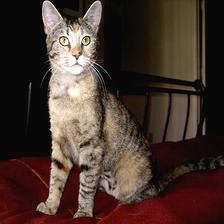

In [8]:
Image.open('/content/PetImages/Cat/10000.jpg')

# Load data in batches directly from disk.

In [9]:
batch_size = 32
img_size = (224, 224)

This function is useful for pre-processing the data into an image and input vector.

In [10]:
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    return img, x

# We will create a training dataset and a validation/test split (70%, 30%) with TensorFlow

In [11]:
# Create the training dataset (70%)
train_ds = tf.keras.utils.image_dataset_from_directory(
  root_dir,
  validation_split=0.3, # 30% reservado para validação/teste
  subset="training",
  seed=123,
  image_size=img_size,
  batch_size=batch_size
)

# Create the validation dataset (remaining 30%)
val_ds = tf.keras.utils.image_dataset_from_directory(
  root_dir,
  validation_split=0.3,
  subset="validation",
  seed=123,
  image_size=img_size,
  batch_size=batch_size
)



Found 24939 files belonging to 2 classes.
Using 17458 files for training.
Found 24939 files belonging to 2 classes.
Using 7481 files for validation.


# Optimize read performance (to avoid slowing down the GPU) for TensorFlow

In [12]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

If everything worked properly, you should have loaded a bunch of images, and split them into two sets: `train`, `val`. The shape of the training data should be (`n`, 224, 224, 3) where `n` is the size of your training set, and the labels should be (`n`, `c`) where `c` is the number of classes (2 in the case of `kagglecatsanddogs_5340`).

Notice that we divided all the data into two subsets -- a training set `train`and a validation set `val`. The reason for this is to properly evaluate the accuracy of our classifier. During training, the optimizer uses the validation set to evaluate its internal performance, in order to determine the gradient without overfitting to the training set. A `test` set is always reserved from the training algorithm, and is only used at the end to evaluate the final accuracy of our model. In this proccess, I will use new images that are not in the kagglecatsanddogs_5340.

Let's quickly look at a few sample images from our dataset.

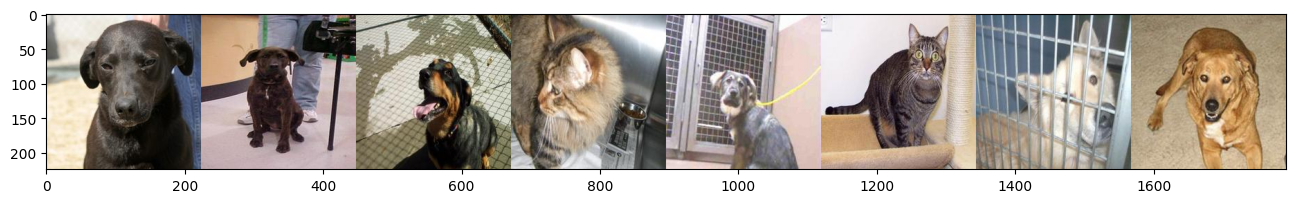

In [15]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root_dir) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [image.load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

### First training a neural net from scratch with TensorFlow

Before doing the transfer learning, let's first build a neural network from scratch for doing classification on our dataset. This will give us a baseline to compare to our transfer-learned network later.

The network we will construct contains 4 alternating convolutional and max-pooling layers, followed by a [dropout](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf) after every other conv/pooling pair. After the last pooling layer, we will attach a fully-connected layer with 256 neurons, another dropout layer, then finally a softmax classification layer for our classes.

Our loss function will be, as usual, categorical cross-entropy loss, and our learning algorithm will be `adam`. It could be [AdaDelta](https://arxiv.org/abs/1212.5701) if desired. Various things about this network can be changed to get better performance, perhaps using a larger network or a different optimizer will help, but for the purposes of this notebook, the goal is to just get an understanding of an approximate baseline for comparison's sake, and so it isn't neccessary to spend much time trying to optimize this network.

Upon compiling the network, let's run `model.summary()` to get a snapshot of its layers.

In [17]:
# Define num_classes from the dataset's class_names
# Calculate num_classes by listing subdirectories in root_dir after exclusions
all_categories = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
# Note: The 'exclude' folders are already removed from the filesystem by previous cell
num_classes = len(all_categories)

model = models.Sequential()

# Add the Rescaling layer first with input_shape
model.add(layers.Rescaling(1./255, input_shape=(224, 224, 3)))

# defined in the dataset (img_size = (224, 224)) and we know that they are RGB images (3 channels)
print("Input dimensions: (224, 224, 3)")

# Now add the rest of the layers, without input_shape for subsequent Conv2D
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256))
model.add(Activation('relu'))

model.add(Dropout(0.5))

model.add(Dense(num_classes))
model.add(Activation('softmax'))

model.summary()

Input dimensions: (224, 224, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 109, 109, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209,058 (4.61 MB)

 Trainable params: 1,209,058 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

We've created a medium-sized network with ~1.2 million weights and biases (the parameters). Most of them are leading into the one pre-softmax fully-connected layer "dense_5".

We can now go ahead and train our model for 10 epochs with a batch size of 128. We'll also record its history so we can plot the loss over time later.

In [18]:
# --- ECONOMICAL COMPILATION ---
# Do NOT use 'keras.utils.to_categorical' on your labels (y_train, y_val).
# Leave the labels as simple integers and change the loss to 'sparse_categorical_crossentropy'.
# This avoids creating gigantic arrays in System RAM.

model.compile(
    optimizer='adam', # or 'adadelta' if you prefer
    loss='sparse_categorical_crossentropy', # <--- Crucial change here. Using 'sparse_' because the labels are not in one-hot encoding.
    metrics=['accuracy']
)


# Convert numpy arrays to TensorFlow tensors for model.fit
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.6462 - loss: 0.6156 - val_accuracy: 0.7331 - val_loss: 0.5260
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.7414 - loss: 0.5191 - val_accuracy: 0.7911 - val_loss: 0.4408
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.7873 - loss: 0.4564 - val_accuracy: 0.7851 - val_loss: 0.4567
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8144 - loss: 0.4072 - val_accuracy: 0.8189 - val_loss: 0.4013
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8375 - loss: 0.3691 - val_accuracy: 0.8401 - val_loss: 0.3613
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8583 - loss: 0.3292 - val_accuracy: 0.8377 - val_loss: 0.3792
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.8723 - loss: 0.3025 - val_accuracy: 0.8484 - val_loss: 0.3463
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8839 - loss: 0.2734 - 

Let's plot the validation loss and validation accuracy over time.

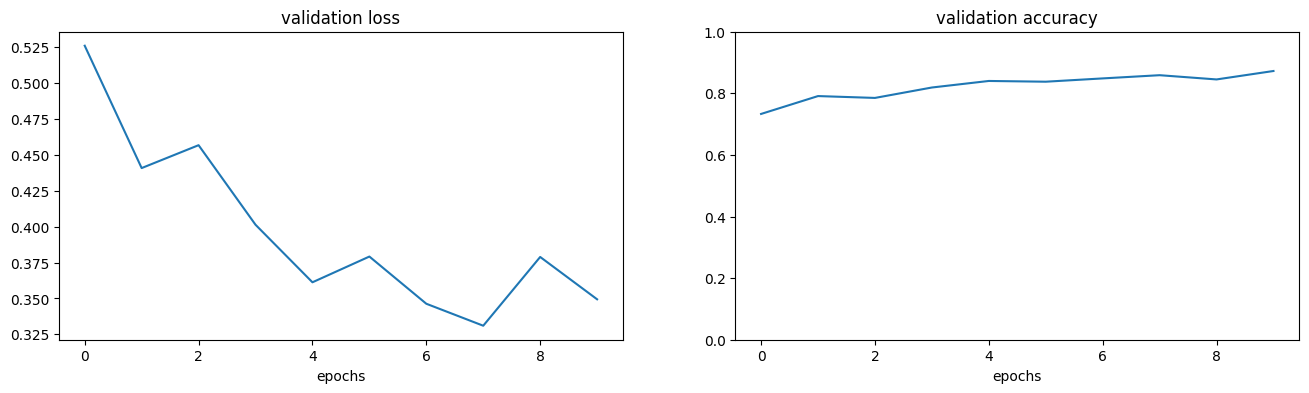

In [20]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
# Changed 'val_acc' to 'val_accuracy' to match Keras metrics
ax2.plot(history.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

Notice that the validation loss begins to actually rise after around 7 epochs, even though validation accuracy remains roughly between 75% and 85%. This suggests our model begins overfitting around then, and best performance would have been achieved if we had stopped early around then. Nevertheless, our accuracy would not have likely been above 80%, and probably lower down.

We can also get a final evaluation by running our model on the training set. Doing so, we get the following results:

In [19]:
# Evaluate the model using the validation dataset (val_ds) since x_test/y_test are no longer used
loss, accuracy = model.evaluate(val_ds, verbose=0)
print('Validation loss:', loss)
print('Validation accuracy:', accuracy)

Validation loss: 0.3494013249874115
Validation accuracy: 0.8724769353866577


Finally, we see that we have achieved a (top-1) accuracy of around 87%. That's not too bad for 17458 images, considering that if we were to use a naive strategy of taking random guesses, we would have only gotten around 1% accuracy.

# Testing the newly trained model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


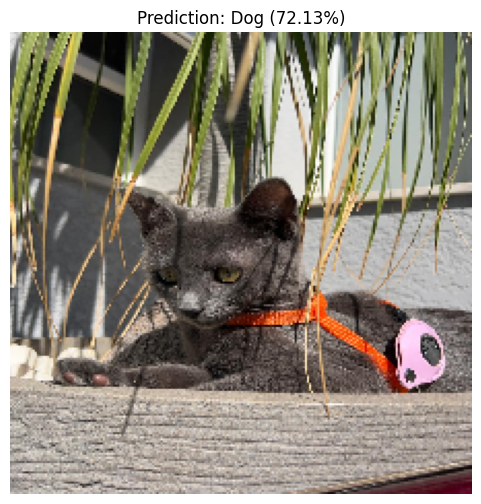

In [23]:
# 1. Select a sample image
sample_path = '//content/WhatsApp Image 2026-05-23 at 20.37.59.jpeg'
img, x = get_image(sample_path)

# 2. Get predictions
probabilities = model.predict([x])[0]

# 3. Find the best class
class_idx = np.argmax(probabilities)
confidence = probabilities[class_idx] * 100

# Since train_ds was prefetched, we get class names from the directory listing (sorted by Keras default)
class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
predicted_label = class_names[class_idx]

# 4. Display results
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis('off')
plt.show()



# Transfer learning by starting with existing network (Keras)

Now we can move on to the main strategy for training an image classifier on our small dataset: by starting with a larger and already trained network.

To start, we will load the VGG16 from keras, which was trained on ImageNet and the weights saved online. If this is your first time loading VGG16, you'll need to wait a bit for the weights to download from the web. Once the network is loaded, we can again inspect the layers with the `summary()` method.

In [22]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 32s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Notice that VGG16 is _much_ bigger than the network we constructed earlier. It contains 13 convolutional layers and two fully connected layers at the end, and has over 138 million parameters, around 100 times as many parameters than the network we made above. Like our first network, the majority of the parameters are stored in the connections leading into the first fully-connected layer.

VGG16 was made to solve ImageNet, and achieves a [8.8% top-5 error rate](https://github.com/jcjohnson/cnn-benchmarks), which means that 91.2% of test samples were classified correctly within the top 5 predictions for each image. It's top-1 accuracy--equivalent to the accuracy metric we've been using (that the top prediction is correct)--is 73%. This is especially impressive since there are not just 97, but 1000 classes, meaning that random guesses would get us only 0.1% accuracy.

In order to use this network for our task, we "remove" the final classification layer, the 1000-neuron softmax layer at the end, which corresponds to ImageNet, and instead replace it with a new softmax layer for our dataset, which contains 97 neurons in the case of the 101_ObjectCategories dataset.

In terms of implementation, it's easier to simply create a copy of VGG from its input layer until the second to last layer, and then work with that, rather than modifying the VGG object directly. So technically we never "remove" anything, we just circumvent/ignore it. This can be done in the following way, by using the keras `Model` class to initialize a new model whose input layer is the same as VGG but whose output layer is our new softmax layer, called `new_classification_layer`. Note: although it appears we are duplicating this large network, internally Keras is actually just copying all the layers by reference, and thus we don't need to worry about overloading the memory.

In [24]:
# make a reference to VGG's input layer
inp = vgg.input

# make a new softmax layer with num_classes neurons
new_classification_layer = Dense(num_classes, activation='softmax')

# connect our new layer to the second to last layer in VGG, and make a reference to it
out = new_classification_layer(vgg.layers[-2].output)

# create a new network between inp and out
model_new = Model(inp, out)


We are going to retrain this network, `model_new` on the new dataset and labels. But first, we need to freeze the weights and biases in all the layers in the network, except our new one at the end, with the expectation that the features that were learned in VGG should still be fairly relevant to the new image classification task. Not optimal, but most likely better than what we can train to in our limited dataset.

By setting the `trainable` flag in each layer false (except our new classification layer), we ensure all the weights and biases in those layers remain fixed, and we simply train the weights in the one layer at the end. In some cases, it is desirable to *not* freeze all the pre-classification layers. If your dataset has enough samples, and doesn't resemble ImageNet very much, it might be advantageous to fine-tune some of the VGG layers along with the new classifier, or possibly even all of them. To do this, you can change the below code to make more of the layers trainable.

In the case of CalTech-101, we will just do feature extraction, fearing that fine-tuning too much with this dataset may overfit. But maybe we are wrong? A good exercise would be to try out both, and compare the results.

So we go ahead and freeze the layers, and compile the new model with exactly the same optimizer and loss function as in our first network, for the sake of a fair comparison. We then run `summary` again to look at the network's architecture.

In [25]:
# make all layers untrainable by freezing weights (except for last layer)
for l, layer in enumerate(model_new.layers[:-1]):
    layer.trainable = False

# ensure the last layer is trainable/not frozen
for l, layer in enumerate(model_new.layers[-1:]):
    layer.trainable = True

# Changed loss to sparse_categorical_crossentropy because labels are integers
model_new.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_new.summary()

Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 8,194 (32.01 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

Looking at the summary, we see the network is identical to the VGG model we instantiated earlier, except the last layer, formerly a 1000-neuron softmax, has been replaced by a new 97-neuron softmax. Additionally, we still have roughly 134 million weights, but now the vast majority of them are "non-trainable params" because we froze the layers they are contained in. We now only have 397,000 trainable parameters, which is actually only a quarter of the number of parameters needed to train the first model.

As before, we go ahead and train the new model, using the same hyperparameters (batch size and number of epochs) as before, along with the same optimization algorithm. We also keep track of its history as we go.

In [26]:
# Updated to use train_ds and val_ds instead of undefined x_train/y_train
history2 = model_new.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 200s 340ms/step - accuracy: 0.9570 - loss: 0.1453 - val_accuracy: 0.9640 - val_loss: 0.1493
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 133s 244ms/step - accuracy: 0.9742 - loss: 0.0866 - val_accuracy: 0.9702 - val_loss: 0.1074
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 133s 243ms/step - accuracy: 0.9769 - loss: 0.0751 - val_accuracy: 0.9691 - val_loss: 0.1268
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 132s 242ms/step - accuracy: 0.9830 - loss: 0.0576 - val_accuracy: 0.9689 - val_loss: 0.1297
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 133s 243ms/step - accuracy: 0.9857 - loss: 0.0430 - val_accuracy: 0.9651 - val_loss: 0.1618
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 133s 244ms/step - accuracy: 0.9876 - loss: 0.0372 - val_accuracy: 0.9659 - val_loss: 0.1511
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 142s 243ms/step - accuracy: 0.9864 - loss: 0.0419 - val_accuracy: 0.9691 - val_loss: 0.1553
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 132s 242ms/step - accuracy: 0.9888 -

Our validation accuracy hovers close to 90% towards the end, which is more than 5% improvement on the original network trained from scratch (meaning that we make the wrong prediction on 20% of samples, rather than 50%).

It's worth noting also that this network actually trains _slightly faster_ than the original network, despite having more than 100 times as many parameters! This is because freezing the weights negates the need to backpropagate through all those layers, saving us on runtime.

Let's plot the validation loss and accuracy again, this time comparing the original model trained from scratch (in blue) and the new transfer-learned model in green.

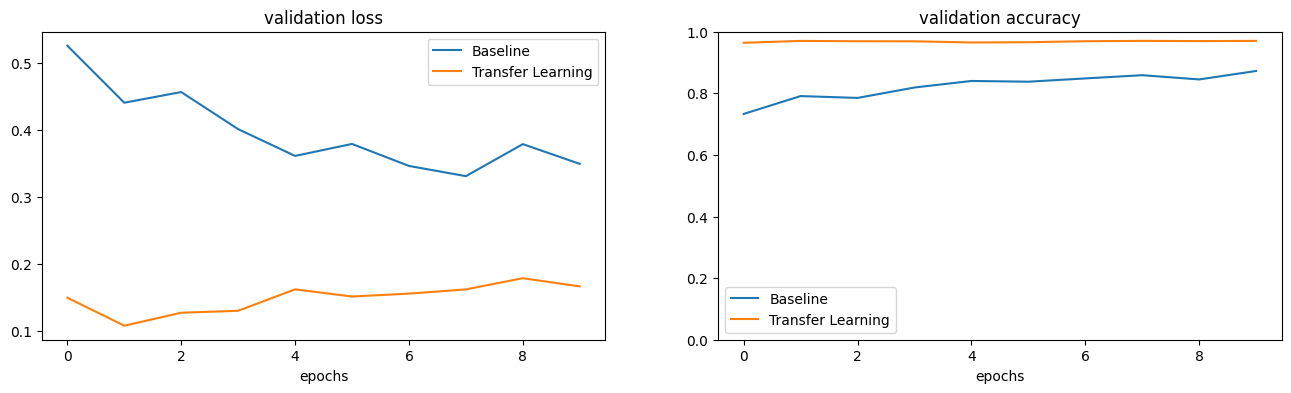

In [27]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"], label="Baseline")
ax.plot(history2.history["val_loss"], label="Transfer Learning")
ax.set_title("validation loss")
ax.set_xlabel("epochs")
ax.legend()

ax2 = fig.add_subplot(122)
# Updated 'val_acc' to 'val_accuracy' for both models
ax2.plot(history.history["val_accuracy"], label="Baseline")
ax2.plot(history2.history["val_accuracy"], label="Transfer Learning")
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)
ax2.legend()

plt.show()

Notice that the baseline's validation loss is significantly volatile and jagged (notice the sharp spikes up at epoch 2 and epoch 8). This instability is also visible in the accuracy curve, which fluctuates and dips slightly at epochs 2, 5, and 8 instead of climbing linearly. The baseline model is struggling with variance in this run. This jagged behavior usually happens due to a learning rate that might be a bit too high for this specific initialization, mini-batch noise, or the model hitting local minima/saddle points that it's bouncing out of.

The validation loss for the Transfer Learning model reaches its absolute minimum very early (at epoch 1, around 0.11). After epoch 1, it exhibits a distinct, prolonged upward trend, peaking at epoch 8 (around 0.18) before a slight dip. While the validation loss is steadily climbing from epoch 1 to 8, the validation accuracy remains completely flat at roughly 97%. This is a textbook example of early-stage overfitting. The model is becoming overly confident in its predictions on the validation set (the error distance/loss is increasing), even though its hard classification choices (accuracy) aren't dropping yet

In [ ]:
# Evaluate the transfer-learned model using the validation dataset (val_ds)
loss, accuracy = model_new.evaluate(val_ds, verbose=0)

print('Test loss (Validation Set):', loss)
print('Test accuracy (Validation Set):', accuracy)

Test loss (Validation Set): 0.17083214223384857
Test accuracy (Validation Set): 0.9703248143196106


To predict a new image, simply run the following code to get the probabilities for each class.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_464
Received: inputs=('Tensor(shape=(1, 224, 224, 3))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


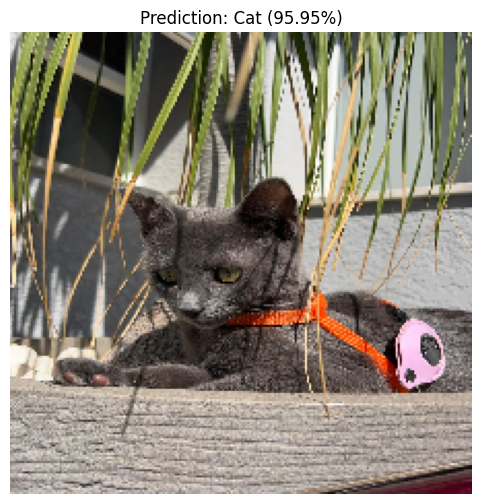

In [28]:
# 1. Select a sample image
sample_path = '/content/WhatsApp Image 2026-05-23 at 20.37.59.jpeg'
img, x = get_image(sample_path)

# 2. Get predictions
probabilities = model_new.predict([x])[0]

# 3. Find the best class
class_idx = np.argmax(probabilities)
confidence = probabilities[class_idx] * 100

# Since train_ds was prefetched, we get class names from the directory listing (sorted by Keras default)
class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
predicted_label = class_names[class_idx]

# 4. Display results
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis('off')
plt.show()